In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# print(torch.cuda.is_available())
torch.manual_seed(42)
np.random.seed(42)

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
device

device(type='cpu')

In [ ]:
# Physical parameters                                
L = 2.0
H = 1.0
T = 1.0
rho = 1000.0
nu = 1e-3                                   
g = 9.81

# opening on the right wall
opening_y_min = 0.30
opening_y_max = 0.70

In [ ]:
# Interior points

N_f = 10000
x_f = np.random.uniform(0, L, N_f)
y_f = np.random.uniform(0, H, N_f)
t_f = np.random.uniform(0, T, N_f)

X_f = np.column_stack([x_f, y_f, t_f])
X_f = torch.tensor(
    X_f,
    dtype=torch.float32,
    device=device,
    requires_grad=True
)

print(X_f.shape)


torch.Size([10000, 2])


In [ ]:
# Generate wall points 

# Bottom boundary (x in [0, L], y=0, t in [0, T])
N_wall = 1000
x_bottom = np.linspace(0, L, N_wall)
bottom_pts = np.column_stack([
    x_bottom,
    np.zeros(N_wall),
    np.linspace(0, T, N_wall)
])

# Left boundary (x=0, y in [0, H], t in [0, T])
y_left = np.linspace(0, H, N_wall)
left_pts = np.column_stack([
    np.zeros(N_wall),
    y_left,
    np.linspace(0, T, N_wall)
])

# Right side wall (0->0.30, 0.70->1)
y_right_bottom_side = np.linspace(0, opening_y_min, N_wall // 2)
y_right_top_side = np.linspace(opening_y_max, H, N_wall // 2)

# (x=L, y=0->0.30, t in [0, T])
right_bottom_pts = np.column_stack([
    np.full(len(y_right_bottom_side), L),
    y_right_bottom_side,
    np.linspace(0, T, len(y_right_bottom_side))
])

# (x=L, y=0.70->1, t in [0, T])
right_top_pts = np.column_stack([
    np.full(len(y_right_top_side), L),
    y_right_top_side,
    np.linspace(0, T, len(y_right_top_side))
])


In [ ]:
# Combining all wall points 
X_wall = np.vstack([left_pts, bottom_pts, right_bottom_pts, right_top_pts])
X_wall = torch.tensor(X_wall, dtype=torch.float32, device=device)
print(X_wall.shape)

torch.Size([3000, 2])


In [ ]:
# Generating opening points
N_open = 500
y_open = np.linspace(opening_y_min, opening_y_max, N_open)
t_open = np.linspace(0, T, N_open)
opening_pts = np.column_stack([
    np.full(len(y_open), L),
    y_open,
    t_open
])
X_open = torch.tensor(opening_pts, dtype=torch.float32, device=device)
X_open.shape

torch.Size([500, 2])

In [ ]:
class PINN(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.network(x)

In [ ]:
model = PINN().to(device)
test_pnts = torch.tensor([[0.2, 1.2, 0.5]], dtype=torch.float32, device=device)

pred = model(test_pnts)
print(pred)


tensor([[0.0815, 0.0609, 0.1203]], grad_fn=<AddmmBackward0>)


In [12]:
print(pred[0,0].item())

0.08153486251831055


In [13]:
def derivatives(output, inputs):
    grad = torch.autograd.grad(
        output,
        inputs,
        grad_outputs=torch.ones_like(output),
        create_graph=True,
        retain_graph=True
    )[0]
    
    return grad

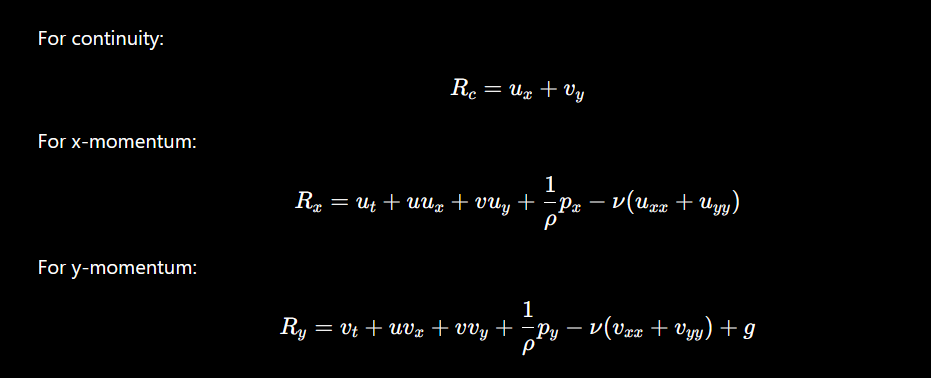

In [ ]:
# continuity loss calculation
def continuity_loss(model, x, y, t):
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)
    X = torch.stack((x, y, t), dim=1)
    
    pred = model(X)
    
    u = pred[:, 0:1]
    v = pred[:, 1:2]
    # p = pred[:, 2:3]
    
    u_x = derivatives(u, x)
    v_y = derivatives(v, y)
    
    R_cont = u_x + v_y
    
    return R_cont

In [ ]:
# x-momentum loss
def x_momentum_loss(model, x, y, t):
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)
    X = torch.stack((x, y, t), dim=1)
    
    pred = model(X)
    
    u = pred[:, 0:1]
    v = pred[:, 1:2]
    p = pred[:, 2:3]
    
    u_x = derivatives(u, x)
    u_y = derivatives(u, y)
    
    u_xx = derivatives(u_x, x)
    u_yy = derivatives(u_y, y)
    
    p_x = derivatives(p, x)
    
    R_x = u*u_x + v*u_y + ((1/rho)*p_x) - nu*(u_xx + u_yy)
    
    return R_x

In [ ]:
# y-momentum loss
def y_momentum_loss(model, x, y, t):
    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)
    X = torch.stack((x, y, t), dim=1)
    
    pred = model(X)
    
    u = pred[:, 0:1]
    v = pred[:, 1:2]
    p = pred[:, 2:3]
    
    v_x = derivatives(v, x)
    v_y = derivatives(v, y)
    
    v_xx = derivatives(v_x, x)
    v_yy = derivatives(v_y, y)
    
    p_y = derivatives(p, y)
    
    R_y = (u * v_x + v * v_y + (1 / rho) * p_y - nu * (v_xx + v_yy) + g)

    return R_y

In [ ]:
print(X_f[:, 0], X_f[:, 1], X_f[:, 2])

tensor([0.3745, 0.9507, 0.7320,  ..., 0.9467, 0.3975, 0.2171],
       grad_fn=<SelectBackward0>) tensor([0.7473, 0.6658, 0.3523,  ..., 0.6074, 0.8866, 0.3445],
       grad_fn=<SelectBackward0>)


In [ ]:
R_cont  = continuity_loss(model, X_f[:, 0], X_f[:, 1], X_f[:, 2])
R_x     = x_momentum_loss(model, X_f[:, 0], X_f[:, 1], X_f[:, 2])
R_y     = y_momentum_loss(model, X_f[:, 0], X_f[:, 1], X_f[:, 2])

print("Continuity residual:",
      R_cont.abs().mean().item())

print("X momentum residual:",
      R_x.abs().mean().item())

print("Y momentum residual:",
      R_y.abs().mean().item())

Continuity residual: 0.0374133363366127
X momentum residual: 0.004996123258024454
Y momentum residual: 9.807047843933105


In [ ]:
def physics_loss():
    x = X_f[:, 0]
    y = X_f[:, 1]
    t = X_f[:, 2]

    R_cont = continuity_loss(model, x, y, t)
    R_x = x_momentum_loss(model, x, y, t)
    R_y = y_momentum_loss(model, x, y, t)

    loss_cont = torch.mean(R_cont**2)
    loss_x = torch.mean(R_x**2)
    loss_y = torch.mean(R_y**2)

    return loss_cont + loss_x + loss_y

In [20]:
# Wall boundary loss (u=0, v=0)
def wall_loss():

    prediction = model(X_wall)

    u_wall = prediction[:, 0]
    v_wall = prediction[:, 1]

    loss_u = torch.mean(u_wall**2)
    loss_v = torch.mean(v_wall**2)

    return loss_u + loss_v

In [21]:
# Opening boundary condition (p=0)
def opening_loss():
    
    prediction = model(X_open)
    p_open = prediction[:, 2]

    return torch.mean(p_open**2)

In [ ]:
X_pressure_ref = torch.tensor(
    [[0.0, H, 0.0]],
    dtype=torch.float32,
    device=device
)

def pressure_reference_loss():

    prediction = model(X_pressure_ref)
    p_ref = prediction[:, 2]

    return torch.mean(p_ref**2)

In [23]:
# Total loss 
def total_loss():

    L_phys = physics_loss()
    L_wall = wall_loss()
    L_open = opening_loss()
    L_ref = pressure_reference_loss()

    loss = ( L_phys + L_wall + L_open + L_ref )

    return loss, L_phys, L_wall, L_open, L_ref

In [24]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [28]:
epochs = 100
loss_history = []
for epoch in range(epochs):
    optimizer.zero_grad()
    (loss, L_phys, L_wall, L_open, L_ref) = total_loss()
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    
    if epoch % 5 == 0:
        print(
            f"Epoch {epoch+1:5d} | "
            f"Total: {loss.item():.3e} | "
            f"Physics: {L_phys.item():3e} | "
            f"Wall: {L_phys.item():3e} | "
            f"Open: {L_phys.item():3e} | "
            
        )

import torch

# Define the file path for the checkpoint
checkpoint_path = "pinn_model_checkpoint_01.pt"

# Create a dictionary containing all necessary states
checkpoint = {
    "epoch": epochs,
    "model_state_dict": model.state_dict(),  # Replace 'model' with your actual model variable name
    "optimizer_state_dict": optimizer.state_dict(),
    "loss_history": loss_history,
}

# Save to disk
torch.save(checkpoint, checkpoint_path)
print(f"Training complete. Checkpoint saved to {checkpoint_path}")

Epoch     1 | Total: 9.485e+01 | Physics: 9.468703e+01 | Wall: 9.468703e+01 | Open: 9.468703e+01 | 
Epoch     6 | Total: 8.861e+01 | Physics: 8.786346e+01 | Wall: 8.786346e+01 | Open: 8.786346e+01 | 
Epoch    11 | Total: 7.180e+01 | Physics: 6.966827e+01 | Wall: 6.966827e+01 | Open: 6.966827e+01 | 
Epoch    16 | Total: 4.157e+01 | Physics: 3.681295e+01 | Wall: 3.681295e+01 | Open: 3.681295e+01 | 
Epoch    21 | Total: 2.062e+01 | Physics: 1.228318e+01 | Wall: 1.228318e+01 | Open: 1.228318e+01 | 
Epoch    26 | Total: 2.543e+01 | Physics: 1.503618e+01 | Wall: 1.503618e+01 | Open: 1.503618e+01 | 
Epoch    31 | Total: 1.621e+01 | Physics: 6.755179e+00 | Wall: 6.755179e+00 | Open: 6.755179e+00 | 
Epoch    36 | Total: 1.680e+01 | Physics: 8.168441e+00 | Wall: 8.168441e+00 | Open: 8.168441e+00 | 
Epoch    41 | Total: 1.459e+01 | Physics: 5.428353e+00 | Wall: 5.428353e+00 | Open: 5.428353e+00 | 
Epoch    46 | Total: 1.385e+01 | Physics: 3.609860e+00 | Wall: 3.609860e+00 | Open: 3.609860e+00 | 


In [ ]:
import torch
import torch.nn as nn

# Make sure this matches the model definition used during training
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.network(x)

# Recreate the model and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Load checkpoint
checkpoint_path = "pinn_model_checkpoint_01.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

# Restore model weights
model.load_state_dict(checkpoint["model_state_dict"])

# Restore optimizer state if needed
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

# Restore extra metadata
epoch = checkpoint["epoch"]
loss_history = checkpoint["loss_history"]

print(f"Loaded checkpoint from {checkpoint_path}")
print(f"Last epoch: {epoch}")
print(f"Loss history length: {len(loss_history)}")

Loaded checkpoint from pinn_model_checkpoint.pt
Last epoch: 500
Loss history length: 500


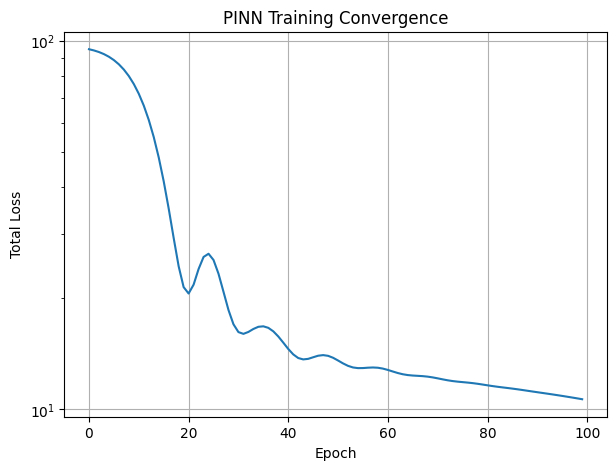

In [30]:
plt.figure(figsize=(7, 5))

plt.semilogy(
    loss_history
)

plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("PINN Training Convergence")

plt.grid(True)
plt.show()

In [ ]:
Nx = 100
Ny = 100
t_plot = 0.5

x = np.linspace(0, L, Nx)
y = np.linspace(0, H, Ny)

X, Y = np.meshgrid(x, y)

XY = np.column_stack([
    X.flatten(),
    Y.flatten(),
    np.full(X.size, t_plot)
])

XY_tensor = torch.tensor(
    XY,
    dtype=torch.float32,
    device=device
)

with torch.no_grad():

    prediction = model(XY_tensor)

u_pred = prediction[:, 0].cpu().numpy()
v_pred = prediction[:, 1].cpu().numpy()
p_pred = prediction[:, 2].cpu().numpy()

u_pred = u_pred.reshape(Ny, Nx)

v_pred = v_pred.reshape(Ny, Nx)p_pred = p_pred.reshape(Ny, Nx)

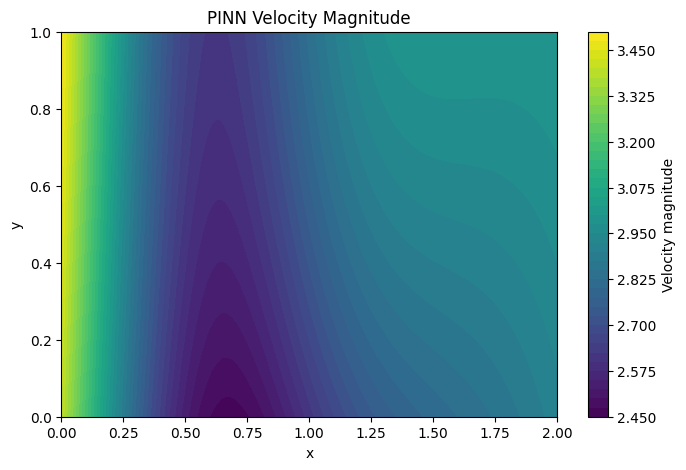

In [32]:
velocity_mag = np.sqrt(
    u_pred**2 + v_pred**2
)

plt.figure(figsize=(8, 5))

plt.contourf(
    X,
    Y,
    velocity_mag,
    levels=50
)

plt.colorbar(
    label="Velocity magnitude"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("PINN Velocity Magnitude")

plt.show()

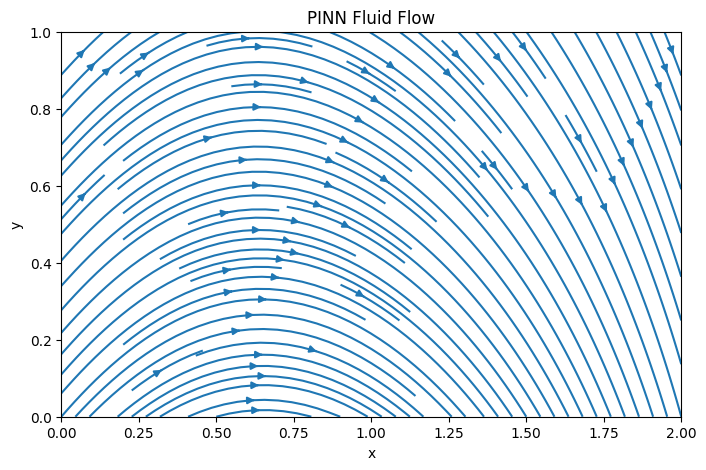

In [33]:
plt.figure(figsize=(8, 5))

plt.streamplot(
    X,
    Y,
    u_pred,
    v_pred,
    density=1.5
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("PINN Fluid Flow")

plt.show()

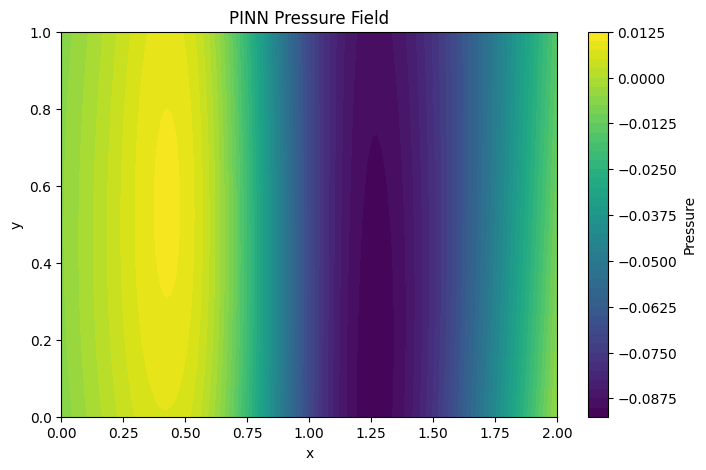

In [34]:
plt.figure(figsize=(8, 5))

plt.contourf(
    X,
    Y,
    p_pred,
    levels=50
)

plt.colorbar(
    label="Pressure"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("PINN Pressure Field")

plt.show()

In [35]:
with torch.no_grad():

    opening_prediction = model(X_open)

u_open = opening_prediction[:, 0].cpu().numpy()
v_open = opening_prediction[:, 1].cpu().numpy()
p_open = opening_prediction[:, 2].cpu().numpy()

In [36]:
for i in range(0, N_open, 50):

    print(
        f"y = {y_open[i]:.3f} m | "
        f"u = {u_open[i]:.5f} m/s | "
        f"v = {v_open[i]:.5f} m/s | "
        f"p = {p_open[i]:.5f}"
    )

y = 0.300 m | u = -0.01484 m/s | v = -0.01519 m/s | p = -0.00137
y = 0.340 m | u = -0.01382 m/s | v = -0.01712 m/s | p = -0.00111
y = 0.380 m | u = -0.01284 m/s | v = -0.01913 m/s | p = -0.00085
y = 0.420 m | u = -0.01189 m/s | v = -0.02123 m/s | p = -0.00058
y = 0.460 m | u = -0.01098 m/s | v = -0.02343 m/s | p = -0.00032
y = 0.500 m | u = -0.01010 m/s | v = -0.02574 m/s | p = -0.00005
y = 0.540 m | u = -0.00926 m/s | v = -0.02817 m/s | p = 0.00022
y = 0.581 m | u = -0.00844 m/s | v = -0.03073 m/s | p = 0.00048
y = 0.621 m | u = -0.00766 m/s | v = -0.03344 m/s | p = 0.00076
y = 0.661 m | u = -0.00691 m/s | v = -0.03630 m/s | p = 0.00103


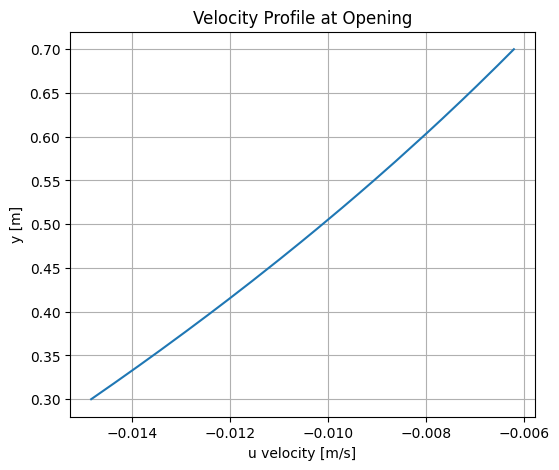

In [37]:
plt.figure(figsize=(6, 5))

plt.plot(
    u_open,
    y_open
)

plt.xlabel("u velocity [m/s]")
plt.ylabel("y [m]")
plt.title("Velocity Profile at Opening")

plt.grid(True)

plt.show()

In [38]:
Q = np.trapezoid(
    u_open,
    y_open
)

print(
    f"Flow rate per unit depth = {Q:.6f} m^2/s"
)

Flow rate per unit depth = -0.004098 m^2/s


In [ ]:
# model = PINNModel()
# num1 = torch.tensor([[2.0]], dtype=torch.float32, device=device)
# num2 = torch.tensor([[3.0]], dtype=torch.float32, device=device)
# num3 = torch.tensor([[4.0]], dtype=torch.float32, device=device)

# output = model(num1, num2, num3)

# u = output[..., 0]
# v = output[..., 1]

# print(u, v)

Two consecutive backward passes succeeded
